In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold,KFold
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import BernoulliNB
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


Preprocessing

In [8]:
df=pd.read_csv('/workspaces/Diabetes-Prediction/Dataset/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [10]:
df.shape

(768, 9)

In [11]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [12]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Imbalance Check

In [13]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [14]:
print(f'Imbalance Difference:{500-268}')

Imbalance Difference:232


Corelation

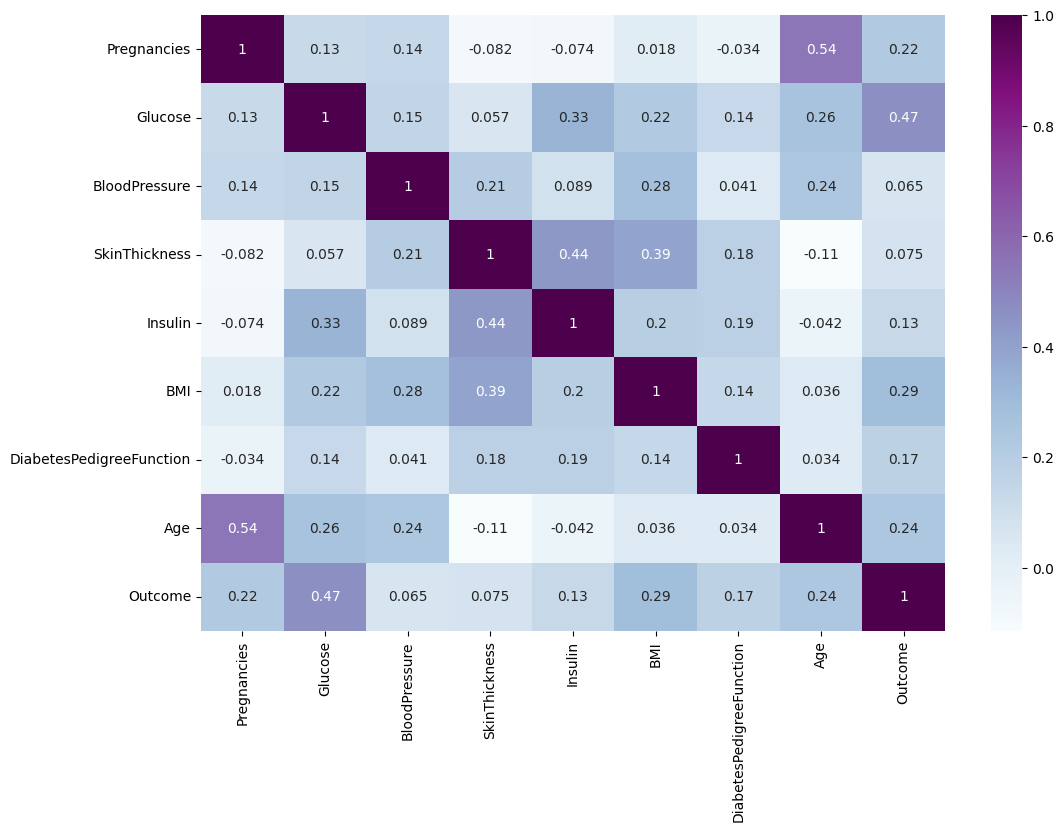

In [15]:
corr=df.corr()
plt.figure(figsize=(12,8))
sn.heatmap(corr,annot=True,cmap='BuPu')
plt.show()

In [16]:
df=df.drop(columns=['BloodPressure','SkinThickness'])
df.columns

Index(['Pregnancies', 'Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction',
       'Age', 'Outcome'],
      dtype='str')

EDA

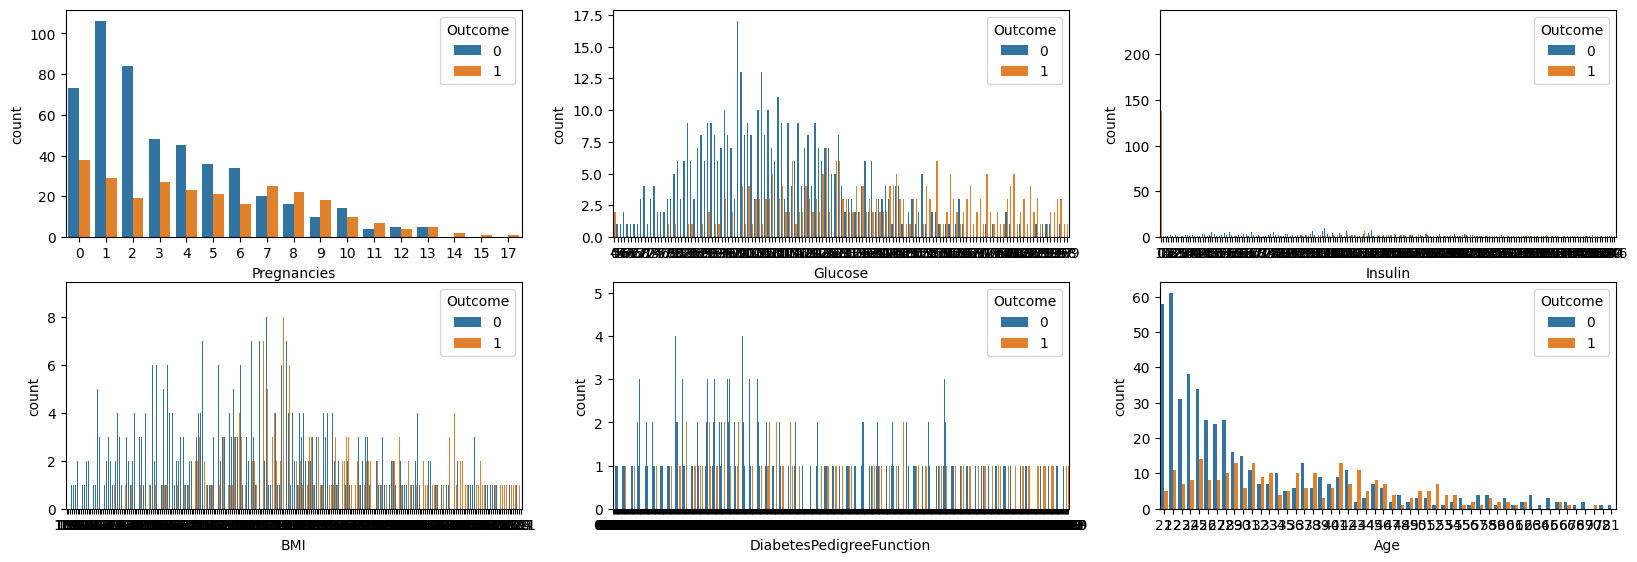

In [17]:
plt.figure(figsize=(20,10))

plt.subplot(3,3,1)
sn.countplot(x='Pregnancies',hue='Outcome',data=df)

plt.subplot(3,3,2)
sn.countplot(x='Glucose',hue='Outcome',data=df)

plt.subplot(3,3,3)
sn.countplot(x='Insulin',hue='Outcome',data=df)

plt.subplot(3,3,4)
sn.countplot(x='BMI',hue='Outcome',data=df)

plt.subplot(3,3,5)
sn.countplot(x='DiabetesPedigreeFunction',hue='Outcome',data=df)

plt.subplot(3,3,6)
sn.countplot(x='Age',hue='Outcome',data=df)

plt.show()

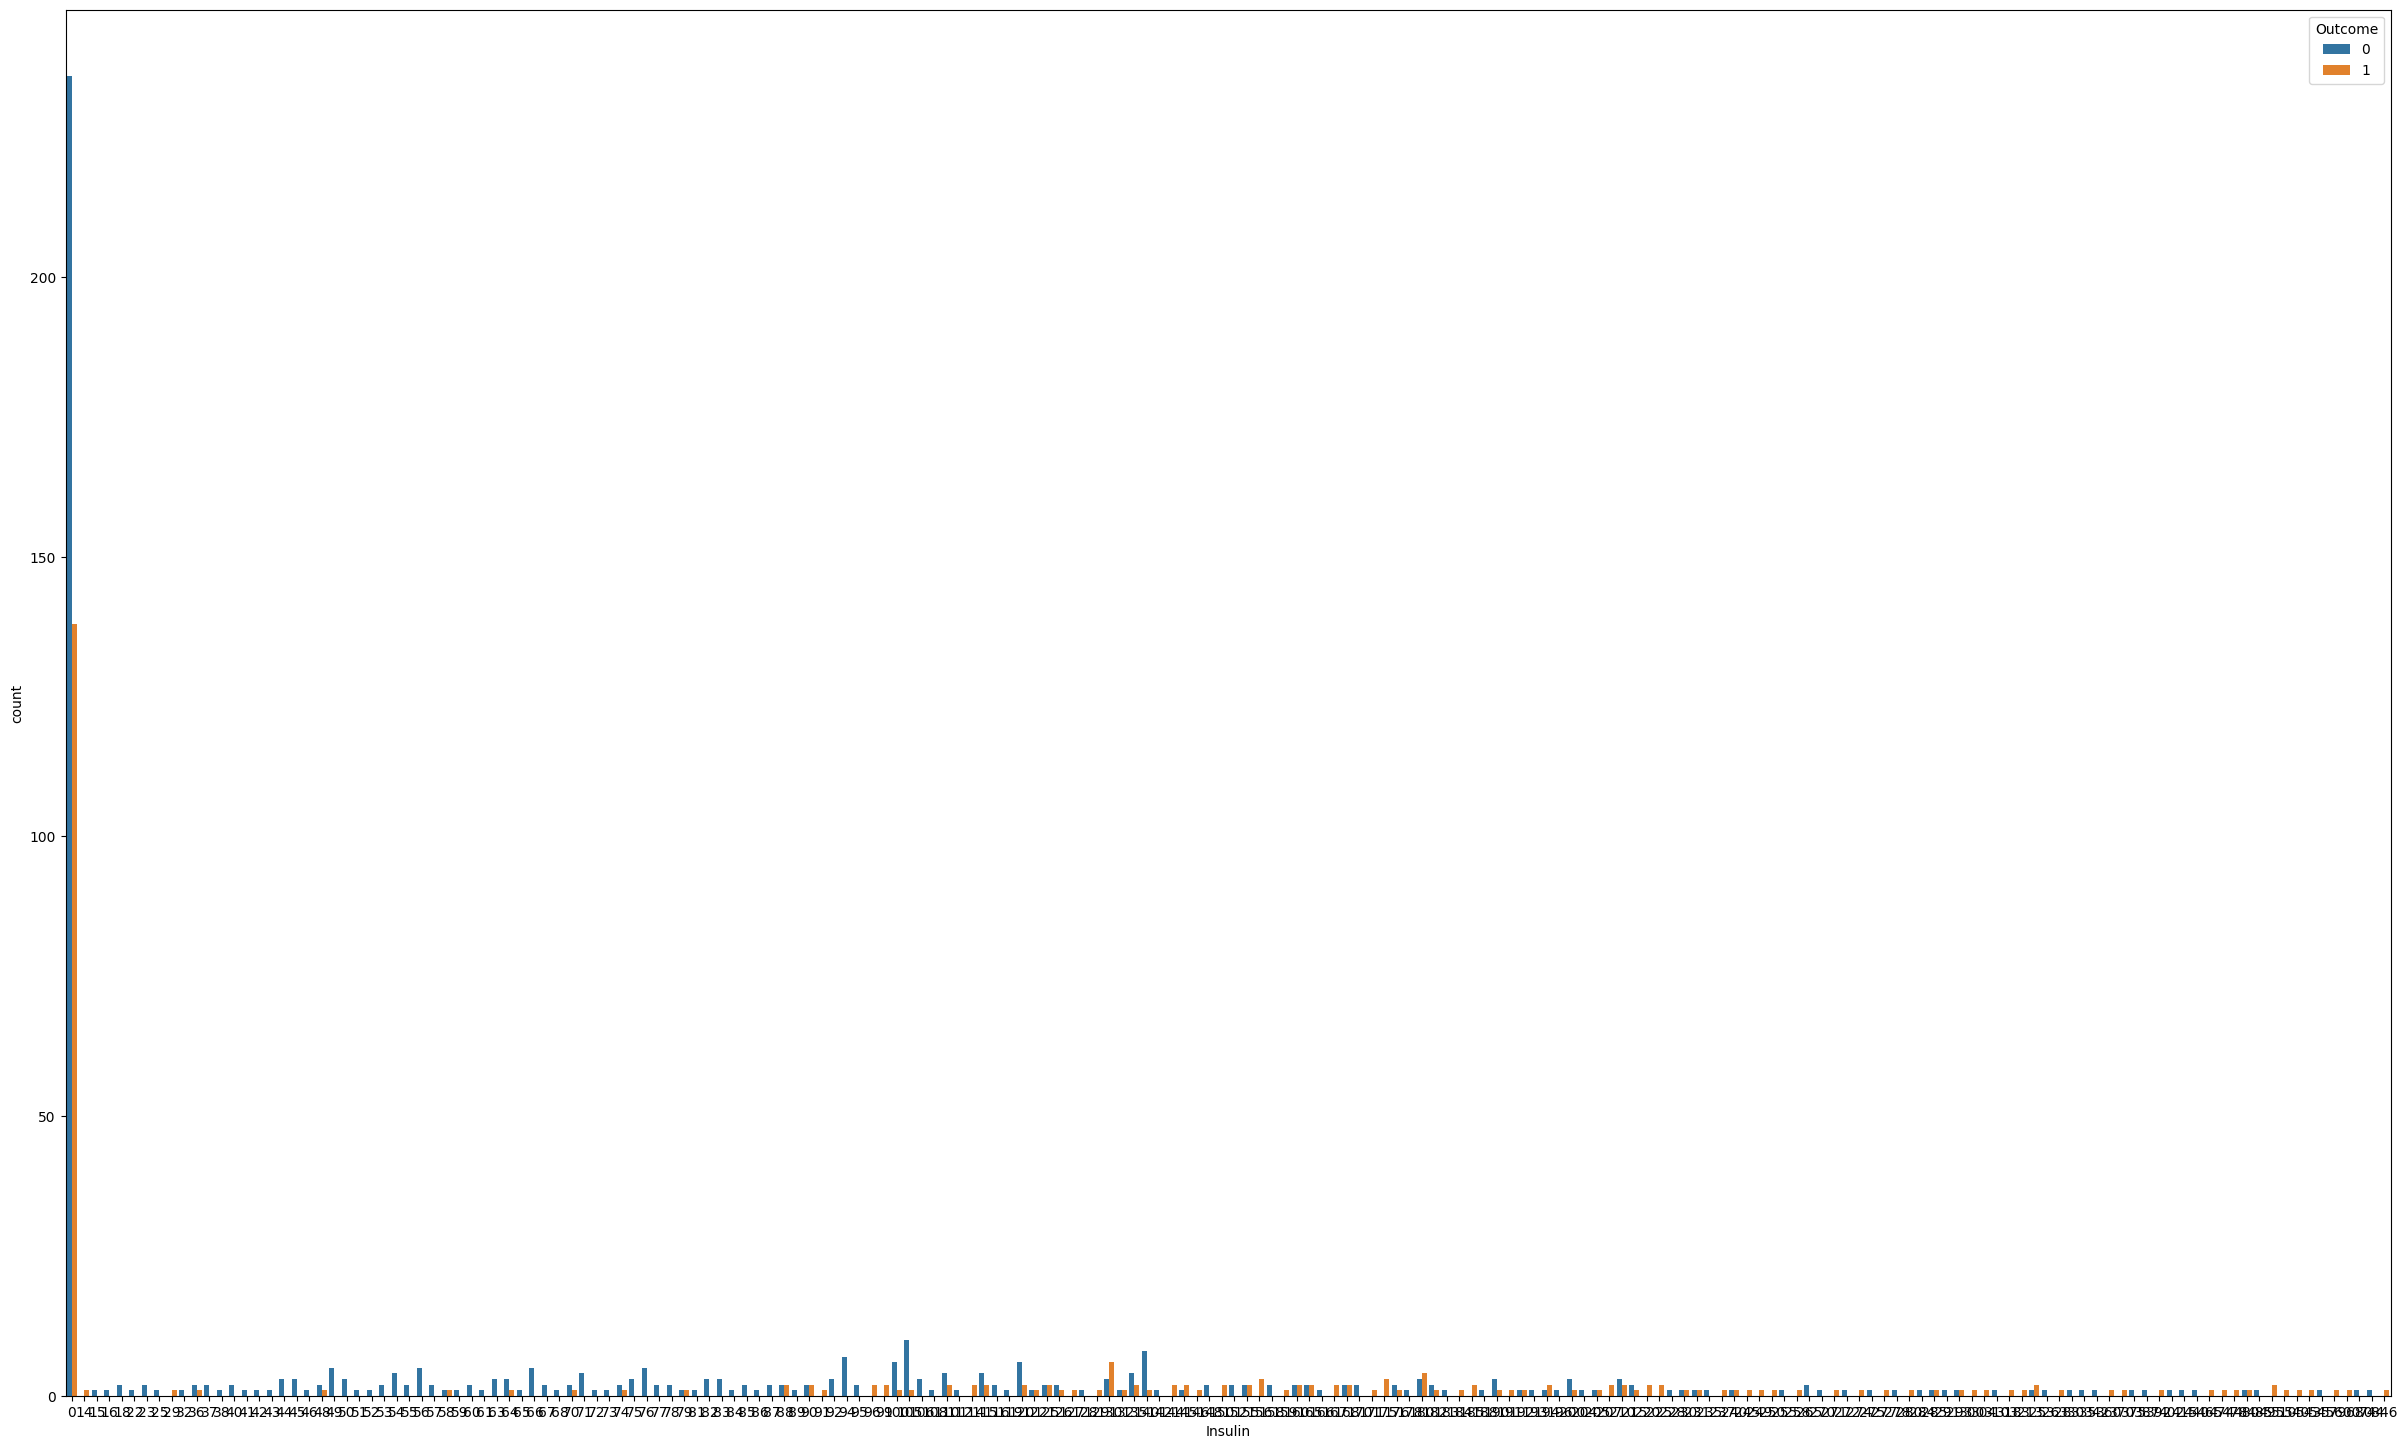

In [18]:
plt.figure(figsize=(30,18))
sn.countplot(x=df['Insulin'],hue='Outcome',data=df)
plt.show()

Train Test Split

In [19]:
x=df.drop(columns='Outcome')
x.head()

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,0,33.6,0.627,50
1,1,85,0,26.6,0.351,31
2,8,183,0,23.3,0.672,32
3,1,89,94,28.1,0.167,21
4,0,137,168,43.1,2.288,33


In [20]:
y=df['Outcome']
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [21]:
print(x.shape)
print(y.shape)

(768, 6)
(768,)


In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

SMOTE

In [24]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()

In [25]:
print(x_train.shape)
print(y_train.shape)

(576, 6)
(576,)


In [26]:
x_train_smote, y_train_smote=smote.fit_resample(x_train,y_train)

print(x_train_smote.shape)
print(y_train_smote.shape)

(754, 6)
(754,)


In [27]:
x_train

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
357,13,129,0,39.9,0.569,44
73,4,129,270,35.1,0.231,23
352,3,61,0,34.4,0.243,46
497,2,81,76,30.1,0.547,25
145,0,102,0,0.0,0.572,21
...,...,...,...,...,...,...
71,5,139,140,28.6,0.411,26
106,1,96,0,22.4,0.207,27
270,10,101,0,45.6,1.136,38
435,0,141,0,42.4,0.205,29


In [28]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train_smote)
x_test=scaler.fit_transform(x_test)

In [29]:
x_train[:5]

array([[ 2.85667377,  0.14456695, -0.68104643,  1.02837199,  0.26632776,
         0.91565461],
       [ 0.05166897,  0.14456695,  1.53051856,  0.35768289, -0.76289777,
        -0.95656583],
       [-0.25999823, -1.9720055 , -0.68104643,  0.25987407, -0.72635722,
         1.09396132],
       [-0.57166543, -1.34948419, -0.05853184, -0.34095159,  0.19933675,
        -0.77825912],
       [-1.19499983, -0.69583682, -0.68104643, -4.54673114,  0.2754629 ,
        -1.13487254]])

Cross Validation

In [30]:
LR_score=cross_val_score(LogisticRegression(),X=x_train,y=y_train_smote,cv=5)
DT_score=cross_val_score(DecisionTreeClassifier(),X=x_train,y=y_train_smote,cv=5)
RF_score=cross_val_score(RandomForestClassifier(random_state=42),X=x_train,y=y_train_smote,cv=5)
KNN_score=cross_val_score(KNeighborsClassifier(),X=x_train,y=y_train_smote,cv=5)
AD_score=cross_val_score(AdaBoostClassifier(random_state=42),X=x_train,y=y_train_smote,cv=5)
GB_score=cross_val_score(GradientBoostingClassifier(random_state=42),X=x_train,y=y_train_smote,cv=5)
Xg_score=cross_val_score(XGBClassifier(random_state=42),X=x_train_smote,y=y_train_smote,cv=5)
SVM_score=cross_val_score(SVC(random_state=42),X=x_train,y=y_train_smote,cv=5)
Lgb_score=cross_val_score(LGBMClassifier(verbose=0,random_state=42),X=x_train,y=y_train_smote,cv=5)
CB_score=cross_val_score(CatBoostClassifier(verbose=0,random_state=42),X=x_train,y=y_train_smote,cv=5)
NB_score=cross_val_score(BernoulliNB(),X=x_train,y=y_train_smote,cv=5)

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature nam

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [31]:
print(f'Logistic Regression : { np.round(LR_score.mean()*100,2)}%')
print(f'Decision Tree : { np.round(DT_score.mean()*100,2)}%')
print(f'Random Forest : { np.round(RF_score.mean()*100,2)}%')
print(f'KNN : { np.round(KNN_score.mean()*100,2)}%')
print(f'AdaBoost : { np.round(AD_score.mean()*100,2)}%')
print(f'Gradient Boosting : { np.round(GB_score.mean()*100,2)}%')
print(f'XGBoost : { np.round(Xg_score.mean()*100,2)}%')
print(f'SVM : { np.round(SVM_score.mean()*100,2)}%')
print(f'LightGBM : { np.round(Lgb_score.mean()*100,2)}%')
print(f'CatBoost : { np.round(CB_score.mean()*100,2)}%')
print(f'BernoulliNB : { np.round(NB_score.mean()*100,2)}%')

Logistic Regression : 74.27%
Decision Tree : 76.79%
Random Forest : 82.89%
KNN : 79.71%
AdaBoost : 78.65%
Gradient Boosting : 79.84%
XGBoost : 79.97%
SVM : 79.31%
LightGBM : 80.51%
CatBoost : 82.36%
BernoulliNB : 71.21%


Hyper parameter Tuning

In [32]:
Rf=RandomForestClassifier(random_state=42)
Rf_params={'n_estimators':[100,150,200,300],
           'max_depth':[None,10,20,30]}
clf=GridSearchCV(Rf,Rf_params,cv=5,scoring='accuracy')
clf.fit(x_train,y_train_smote)
print(clf.best_params_)
print(clf.best_score_ )

{'max_depth': 20, 'n_estimators': 100}
0.8302428256070641


{'max_depth': 20, 'n_estimators': 100}
0.8302428256070641

In [33]:
Cb=CatBoostClassifier(verbose=0,random_state=42)
Cb_params={'iterations':[300,500],
    'learning_rate':[0.01,0.05,0.1],
    'depth':[4,6,8]
}
clf=GridSearchCV(Cb,Cb_params,cv=5,scoring='accuracy')
clf.fit(x_train,y_train_smote)
print(clf.best_params_)
print(clf.best_score_)

{'depth': 8, 'iterations': 500, 'learning_rate': 0.05}
0.8249359823399558


{'depth': 8, 'iterations': 500, 'learning_rate': 0.05}
0.8249359823399558

In [34]:
cat_model=CatBoostClassifier(verbose=0,depth=4,iterations=500,learning_rate=0.05)
cat_model.fit(x_train,y_train_smote)

cat_pred=cat_model.predict(x_test)
print(cat_pred)

[1 0 0 1 1 1 0 1 1 1 0 1 0 1 0 1 0 0 1 1 1 0 0 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 1 0 1 0 1 1 0 0 1 1 0 0 1 0 1 1 1 0 0 1 0 1 1 1 1 0 1 0 1 0 1 0 1 1 0 0 0
 0 1 0 0 0 0 1 0 0 0 1 1 1 1 1 0 0 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 0
 1 0 1 1 1 1 1 0 1 0 0 1 0 0 0 1 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0
 1 1 0 1 0 0 0 1 0 1 1 0 0 1 0 0 0 1 0 0 1 1 1 0 1 0 1 0 0 1 1 1 1 1 0 1 1
 0 0 0 1 0 0 0]


In [36]:
accuracy_score(cat_pred,y_test)

0.6927083333333334

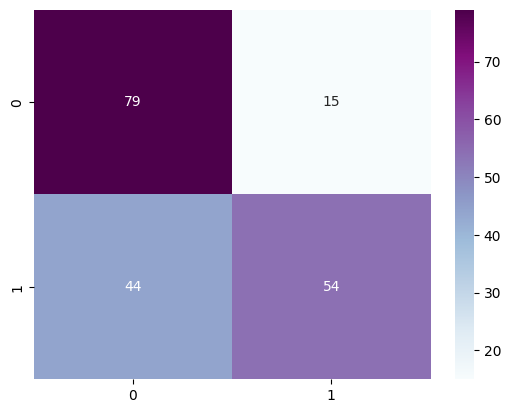

In [37]:
cat_cm=confusion_matrix(cat_pred,y_test)
cat_cm
sn.heatmap(cat_cm,annot=True,cmap='BuPu')
plt.show()

In [38]:
model=RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42)
model.fit(x_train,y_train_smote)

y_prob=model.predict_proba(x_test)[:,1]
y_pred=np.where(y_prob>0.5,1,0)
y_pred

array([1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0])

In [39]:
model.score(x_test,y_test)

0.7135416666666666

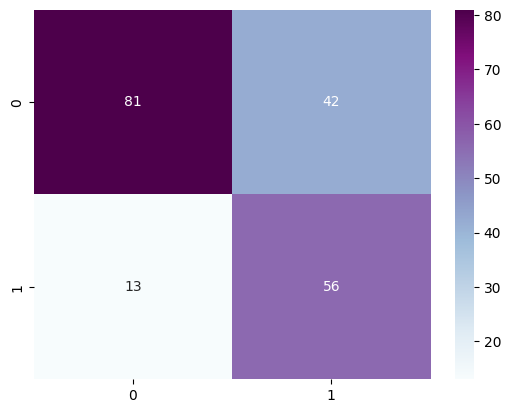

In [40]:
cm=confusion_matrix(y_test,y_pred)
cm
sn.heatmap(cm,annot=True,cmap='BuPu')
plt.show()

In [41]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.66      0.75       123
           1       0.57      0.81      0.67        69

    accuracy                           0.71       192
   macro avg       0.72      0.74      0.71       192
weighted avg       0.76      0.71      0.72       192



In [42]:
x_train=pd.DataFrame(x_train)
x_train.columns

RangeIndex(start=0, stop=6, step=1)

Saving the model

In [44]:
import joblib
joblib.dump(model,'/workspaces/Diabetes-Prediction/Models/dibetes.pkl')
joblib.dump(x_train.columns.to_list(),'/workspaces/Diabetes-Prediction/Models/feature_column.pkl')

['/workspaces/Diabetes-Prediction/Models/feature_column.pkl']

PowerBi Exports

In [47]:
Train_df=x_train.copy()
Train_df["Outcome"]=y_train_smote.values

Train_df.to_csv("/workspaces/Diabetes-Prediction/PowerBi/Actual_value.csv",index=False)

In [48]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print(f'Final Accuracy:{accuracy*100:.2f}%')

accuracy_df=pd.DataFrame({
    'Metrics':['Accuracy'],
    'Value':[accuracy]
})
accuracy_df.to_csv("/workspaces/Diabetes-Prediction/PowerBi/accuracy_metrics.csv", index=False)

Final Accuracy:71.35%
